# IndexProvider

In [ ]:
import os
import sys
import glob

from netCDF4 import Dataset
import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.utils.data.distributed import DistributedSampler
import torch.nn.functional as F
import matplotlib.pyplot as plt


final indexer

In [35]:
class PaddedIndexProvider:
    def __init__(self, mx, my, N, batch_size=32, subset_fraction=1.0):
        self.padding = N
        self.effective_mx = mx + 2 * self.padding
        self.effective_my = my + 2 * self.padding
        self.N = N
        self.batch_size = batch_size
        self.subset_fraction = subset_fraction # P% e.g. 0.2
        
        self.max_x = self.effective_mx - N
        self.max_y = self.effective_my - N
        self.stride = max(1, N)
        
        self.x_bases = np.arange(0, self.max_x + 1, self.stride)
        self.y_bases = np.arange(0, self.max_y + 1, self.stride)
        
        xv, yv = np.meshgrid(self.x_bases, self.y_bases)
        self.base_coords = torch.stack([
            torch.from_numpy(xv.flatten()).float(),
            torch.from_numpy(yv.flatten()).float()
        ], dim=1)
        
        # Calculate how many windows to pick per epoch
        self.num_total_windows = len(self.base_coords)
        self.num_subset = max(1, int(self.num_total_windows * self.subset_fraction))

    def get_epoch_indices(self):
        shift_x = torch.randint(0, self.stride, (1,)).item()
        shift_y = torch.randint(0, self.stride, (1,)).item()
        
        coords = self.base_coords.clone()
        coords[:, 0] += shift_x
        coords[:, 1] += shift_y
        
        jitter = torch.randint(-1, 2, coords.shape).float()
        coords += jitter
        
        coords[:, 0] = torch.clamp(coords[:, 0], 0, self.max_x)
        coords[:, 1] = torch.clamp(coords[:, 1], 0, self.max_y)
        
        # Shuffle and take only the P% subset
        shuffled = coords[torch.randperm(self.num_total_windows)]
        return shuffled[:self.num_subset].long()

    def get_batches(self):
        indices = self.get_epoch_indices()
        for i in range(0, len(indices), self.batch_size):
            yield indices[i : i + self.batch_size]

In [ ]:
mx=81
my=41
N=5
epochs=20
provider = PaddedIndexProvider(mx, my, N, batch_size=32, subset_fraction=0.2)
epoch_indices = provider.get_epoch_indices()
batch_indices = provider.get_batches()
epoch_indices.shape

Total Windows available: 180
Windows used per epoch (20.0%): 36


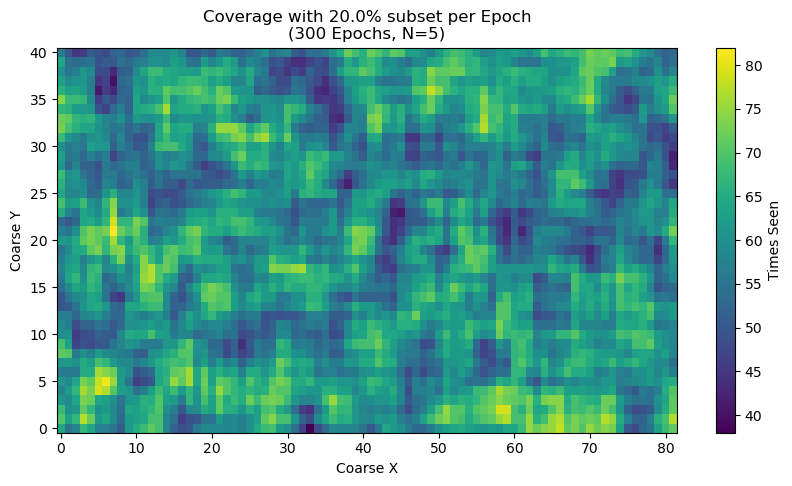

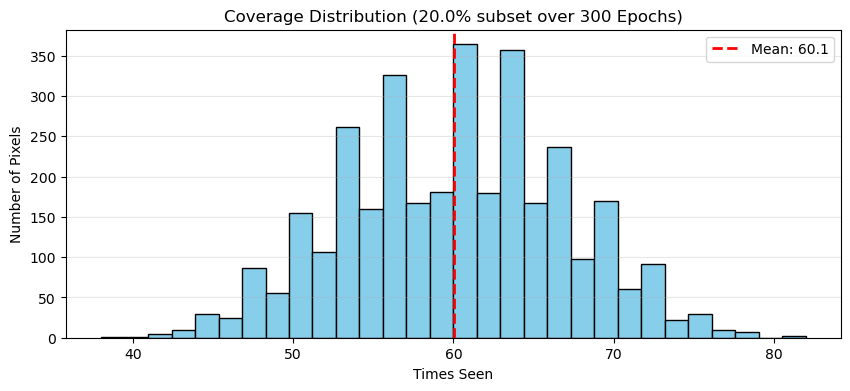

Stats: Min=38.0, Max=82.0
Total Domain Covered: 100.00%


In [51]:
def analyze_padded_indexer_coverage(mx, my, N, epochs=20, subset_p=0.2):
    # Initialize with subset_fraction
    provider = PaddedIndexProvider(mx, my, N, batch_size=64, subset_fraction=subset_p)
    coverage_map = torch.zeros(mx, my)
    pad = provider.padding

    print(f"Total Windows available: {provider.num_total_windows}")
    print(f"Windows used per epoch ({subset_p*100}%): {provider.num_subset}")

    for epoch in range(epochs):
        epoch_indices = provider.get_epoch_indices()
        
        for idx in range(len(epoch_indices)):
            px, py = epoch_indices[idx][0].item(), epoch_indices[idx][1].item()
            
            orig_x_start = max(0, px - pad)
            orig_x_end = min(mx, px - pad + N)
            orig_y_start = max(0, py - pad)
            orig_y_end = min(my, py - pad + N)
            
            if orig_x_start < orig_x_end and orig_y_start < orig_y_end:
                coverage_map[orig_x_start:orig_x_end, orig_y_start:orig_y_end] += 1

    # --- PLOTTING HEATMAP ---
    plt.figure(figsize=(10, 5))
    plt.imshow(coverage_map.numpy().T, cmap='viridis', origin='lower', aspect='auto')
    plt.colorbar(label='Times Seen')
    plt.title(f"Coverage with {subset_p*100}% subset per Epoch\n({epochs} Epochs, N={N})")
    plt.xlabel("Coarse X")
    plt.ylabel("Coarse Y")
    plt.show()

    # --- PLOTTING HISTOGRAM ---
    coverage_flat = coverage_map.flatten().numpy()
    plt.figure(figsize=(10, 4))
    plt.hist(coverage_flat, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(coverage_flat.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {coverage_flat.mean():.1f}')
    plt.title(f"Coverage Distribution ({subset_p*100}% subset over {epochs} Epochs)")
    plt.xlabel("Times Seen")
    plt.ylabel("Number of Pixels")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    covered_percent = (coverage_map > 0).float().mean() * 100
    print(f"Stats: Min={coverage_map.min().item()}, Max={coverage_map.max().item()}")
    print(f"Total Domain Covered: {covered_percent:.2f}%")

if __name__ == "__main__":
    # Test with only 10% of windows over 50 epochs
    analyze_padded_indexer_coverage(mx=82, my=41, N=5, epochs=300, subset_p=0.2)

# IndexProvider End

Running simulation: 10 iterations, 100 patches each.

Coverage counting completed.


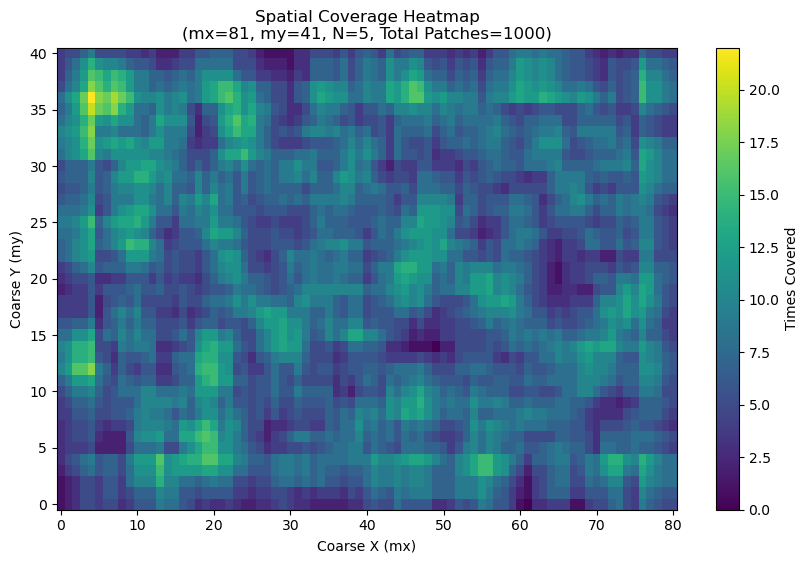

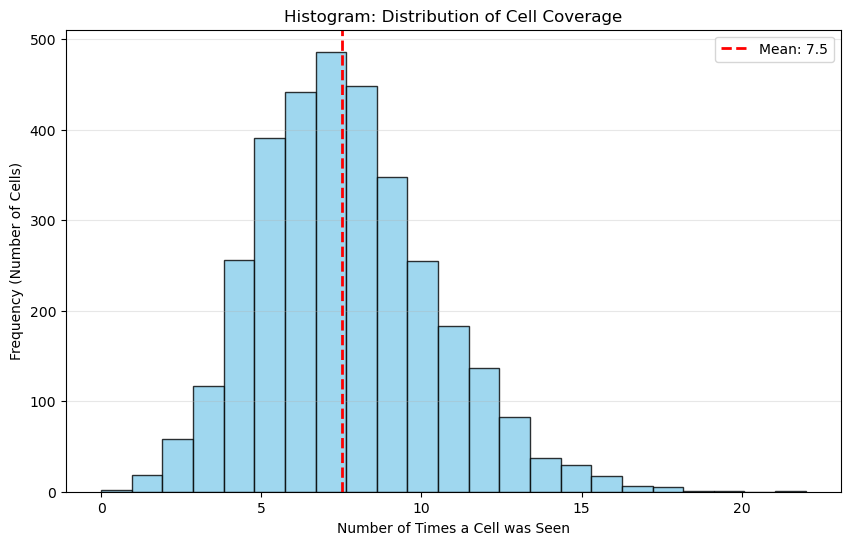

------------------------------
Coverage Stats for 81x41 grid:
  Min times seen: 0
  Max times seen: 22
  Average (Mean): 7.53
  Total cells covered: 3319 / 3321 (99.9%)
------------------------------


In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ------------------------------------------------------------------
# Track and plot coverage with Clamping Logic and Histogram
# ------------------------------------------------------------------
def track_and_plot_coarse_coverage(
    mx, my, N, num_iterations=50, patches_per_iter=200
):
    """
    Counts how many times each cell (mx, my) is covered using Clamped Padding logic.
    Plots both a spatial heatmap and a histogram of the coverage counts.
    """
    coverage_map = torch.zeros(mx, my, dtype=torch.float32)
    
    for it in range(num_iterations):
        # Improved Sampling: Clamped Padding Logic
        x_starts = torch.randint(-(N // 2), mx - (N // 2), (patches_per_iter,))
        y_starts = torch.randint(-(N // 2), my - (N // 2), (patches_per_iter,))
        
        x_starts = torch.clamp(x_starts, 0, mx - N)
        y_starts = torch.clamp(y_starts, 0, my - N)
        
        for x_start, y_start in zip(x_starts, y_starts):
            xs, ys = x_start.item(), y_start.item()
            # Mark the N x N block in the coverage map
            coverage_map[xs : xs + N, ys : ys + N] += 1

    print("\nCoverage counting completed.")
    
    # --- PLOT 1: SPATIAL HEATMAP ---
    plt.figure(figsize=(10, 6))
    plt.imshow(coverage_map.numpy().T, cmap='viridis', origin='lower', aspect='auto')
    plt.colorbar(label='Times Covered')
    plt.title(f"Spatial Coverage Heatmap\n(mx={mx}, my={my}, N={N}, Total Patches={num_iterations * patches_per_iter})")
    plt.xlabel("Coarse X (mx)")
    plt.ylabel("Coarse Y (my)")
    plt.show()
    
    # --- PLOT 2: COVERAGE HISTOGRAM ---
    coverage_flat = coverage_map.flatten().numpy()
    
    plt.figure(figsize=(10, 6))
    plt.hist(coverage_flat, bins=int(coverage_flat.max() - coverage_flat.min() + 1), 
             color='skyblue', edgecolor='black', alpha=0.8)
    
    # Vertical line for the mean coverage
    plt.axvline(coverage_flat.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {coverage_flat.mean():.1f}')
    
    plt.title("Histogram: Distribution of Cell Coverage")
    plt.xlabel("Number of Times a Cell was Seen")
    plt.ylabel("Frequency (Number of Cells)")
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.show()
    
    # Stats Summary
    print("-" * 30)
    print(f"Coverage Stats for {mx}x{my} grid:")
    print(f"  Min times seen: {coverage_map.min().item():.0f}")
    print(f"  Max times seen: {coverage_map.max().item():.0f}")
    print(f"  Average (Mean): {coverage_flat.mean():.2f}")
    print(f"  Total cells covered: {(coverage_map > 0).sum().item()} / {mx * my} ({(coverage_map > 0).float().mean()*100:.1f}%)")
    print("-" * 30)
    
    return coverage_map

if __name__ == "__main__":
    # Parameters
    mx, my = 81, 41          
    N = 5                     
    num_iterations = 10       
    patches_per_iter = 100    

    print(f"Running simulation: {num_iterations} iterations, {patches_per_iter} patches each.")
    coverage_map = track_and_plot_coarse_coverage(mx, my, N, num_iterations, patches_per_iter)

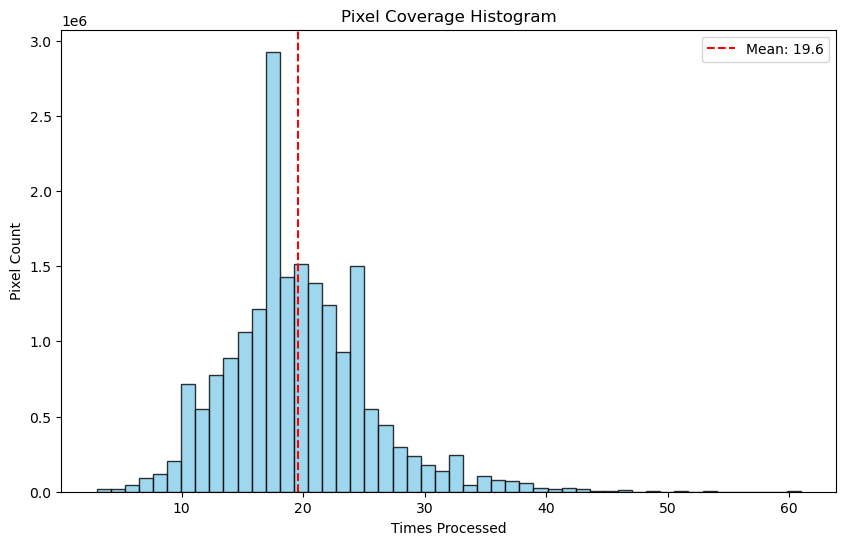

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Dummy magnifier
# ------------------------------------------------------------------
def dummy_magnifier(patch_input):
    out = patch_input[:, 0:1, :, :, :] + torch.randn_like(patch_input[:, 0:1, :, :, :]) * 0.03
    return out

# ------------------------------------------------------------------
# Prepare patch input
# ------------------------------------------------------------------

def prepare_patch_input(
    coarse_u,          # Input: Coarse u from global model [nb, mx, my, nt]
    fine_bed,          # Input: Full high-resolution bed topography [nb, nx, ny]
    i_start,           # Starting row index in coarse grid (int)
    j_start,           # Starting column index in coarse grid (int)
    N,                 # Coarse patch size (N x N coarse pixels)
    f,                 # Upscaling factor (each coarse pixel becomes f x f fine pixels)
    device             # Device to place the final tensor on ('cuda' or 'cpu')
):
    """
    Prepares one N x N coarse patch for input to the magnifier model.
    
    What it does:
    1. Extracts an N x N patch from the coarse u.
    2. Upsamples (interpolates) that patch to fine resolution: N*f x N*f.
    3. Extracts the matching fine-resolution bed patch.
    4. Broadcasts the static bed patch across the time dimension (nt).
    5. Concatenates interpolated coarse u + fine bed along the channel dimension.
    
    Returns:
        patch_input: [nb, 2, P_fine, P_fine, nt]
        where P_fine = N * f
        Channel 0: interpolated coarse u (low-frequency guide)
        Channel 1: fine-resolution bed (static, high-detail local info)
    """
    # Get batch size and time dimension from coarse u
    nb = coarse_u.shape[0]
    nt = coarse_u.shape[-1]

    # Calculate fine patch spatial size
    P_fine = N * f

    # Step 1: Extract the N x N coarse u patch
    # Result shape: [nb, N, N, nt]
    coarse_patch = coarse_u[:, i_start:i_start + N, j_start:j_start + N, :]

    # Step 2: Interpolate coarse patch to fine resolution
    # Permute to [nb, nt, N, N] so we can interpolate spatial dims only
    coarse_patch = coarse_patch.permute(0, 3, 1, 2)  # [nb, nt, N, N]

    # Bilinear upsampling (scale_factor applies only to spatial dims)
    # Note: scale_factor cast to float to avoid type issues in some PyTorch versions
    interp_u = F.interpolate(
        coarse_patch,
        scale_factor=(float(f), float(f)),
        mode='bilinear',
        align_corners=False
    )

    # Back to original order: [nb, P_fine, P_fine, nt]
    interp_u = interp_u.permute(0, 2, 3, 1)

    # Step 3: Extract corresponding fine bed patch
    # Fine starting indices = coarse start * upscaling factor
    i_f = i_start * f
    j_f = j_start * f

    # Slice the fine bed [nb, nx, ny] → [nb, P_fine, P_fine]
    bed_patch = fine_bed[:, i_f:i_f + P_fine, j_f:j_f + P_fine]

    # Step 4: Make bed time-aware (static bed, repeat across nt)
    # Result: [nb, P_fine, P_fine, nt]
    bed_patch = bed_patch.unsqueeze(-1).expand(-1, -1, -1, nt)

    # Step 5: Combine inputs along channel dimension
    # interp_u.unsqueeze(1) → [nb, 1, P_fine, P_fine, nt]
    # bed_patch.unsqueeze(1) → [nb, 1, P_fine, P_fine, nt]
    patch_input = torch.cat([interp_u.unsqueeze(1), bed_patch.unsqueeze(1)], dim=1)
    # Final shape: [nb, 2, P_fine, P_fine, nt]

    # Move to target device
    return patch_input.to(device)

# ------------------------------------------------------------------
# Inference loop using Clamped Padding Logic
# ------------------------------------------------------------------
def run_full_domain_inference_pure_random(
    coarse_u, fine_bed, N=7, f=8, num_iterations=10, patches_per_iter=100, device='cuda'
):
    nb, mx, my, nt = coarse_u.shape
    nx, ny = fine_bed.shape[1], fine_bed.shape[2]
    P_fine = N * f

    accumulated = torch.zeros(nb, nx, ny, nt, device=device)
    weight_map = torch.zeros(nb, nx, ny, nt, device=device)

    for it in range(num_iterations):
        print(f"  Iteration {it+1}/{num_iterations}", end='\r')

        # Clamped Padding Logic
        x_starts = torch.randint(-(N // 2), mx - (N // 2), (patches_per_iter,), device=device)
        y_starts = torch.randint(-(N // 2), my - (N // 2), (patches_per_iter,), device=device)
        
        x_starts = torch.clamp(x_starts, 0, mx - N)
        y_starts = torch.clamp(y_starts, 0, my - N)

        for idx in range(patches_per_iter):
            i = x_starts[idx].item()
            j = y_starts[idx].item()

            patch_input = prepare_patch_input(coarse_u, fine_bed, i, j, N, f, device)
            patch_output = dummy_magnifier(patch_input)

            i_fine, j_fine = i * f, j * f
            accumulated[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += patch_output.squeeze(1)
            weight_map[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += 1

    high_res_u = accumulated / weight_map.clamp(min=1e-6)
    return high_res_u, weight_map


def run_full_domain_inference_parallel(
    coarse_u, fine_bed, N=7, f=8, num_iterations=10, patches_per_iter=100, device='cuda'
):
    nb, mx, my, nt = coarse_u.shape
    nx, ny = fine_bed.shape[1], fine_bed.shape[2]
    P_fine = N * f

    accumulated = torch.zeros(nb, nx, ny, nt, device=device)
    weight_map = torch.zeros(nb, nx, ny, nt, device=device)

    for it in range(num_iterations):
        print(f"  Iteration {it+1}/{num_iterations}", end='\r')

        # 1. Generate all starts at once (Clamped Padding Logic)
        x_starts = torch.randint(-(N // 2), mx - (N // 2), (patches_per_iter,), device=device)
        y_starts = torch.randint(-(N // 2), my - (N // 2), (patches_per_iter,), device=device)
        x_starts = torch.clamp(x_starts, 0, mx - N)
        y_starts = torch.clamp(y_starts, 0, my - N)

        # 2. Batch Patch Extraction
        # We prepare a list of patch inputs to stack them into one big batch
        # Note: If your GPU memory is limited, you can split patches_per_iter 
        # into smaller sub-batches (e.g., 32 at a time).
        patch_list = []
        for idx in range(patches_per_iter):
            i, j = x_starts[idx].item(), y_starts[idx].item()
            # prepare_patch_input returns [nb, 2, P_fine, P_fine, nt]
            patch_list.append(prepare_patch_input(coarse_u, fine_bed, i, j, N, f, device))
        
        # Combined batch: [patches_per_iter * nb, 2, P_fine, P_fine, nt]
        batch_input = torch.cat(patch_list, dim=0)

        # 3. Parallel Magnifier Execution
        # Process all patches at once on the GPU
        batch_output = dummy_magnifier(batch_input) # Output: [TotalBatch, 1, P_fine, P_fine, nt]
        batch_output = batch_output.squeeze(1) # [TotalBatch, P_fine, P_fine, nt]

        # 4. Optimized Accumulation
        # We still loop to place them back, but the "heavy lifting" (the model) was parallel
        for idx in range(patches_per_iter):
            i, j = x_starts[idx].item(), y_starts[idx].item()
            i_f, j_f = i * f, j * f
            
            # Extract the specific output for this patch from the batch
            # batch_output indices: [patch_idx * nb : (patch_idx + 1) * nb]
            accumulated[:, i_f:i_f+P_fine, j_f:j_f+P_fine, :] += batch_output[idx*nb : (idx+1)*nb]
            weight_map[:, i_f:i_f+P_fine, j_f:j_f+P_fine, :] += 1

    high_res_u = accumulated / weight_map.clamp(min=1e-6)
    return high_res_u, weight_map

def plot_coverage_histogram(weight_map):
    coverage = weight_map.squeeze(0).cpu().numpy().flatten()
    coverage = coverage[coverage > 0] 

    plt.figure(figsize=(10, 6))
    plt.hist(coverage, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
    plt.axvline(np.mean(coverage), color='red', linestyle='dashed', label=f'Mean: {np.mean(coverage):.1f}')
    plt.title("Pixel Coverage Histogram")
    plt.xlabel("Times Processed")
    plt.ylabel("Pixel Count")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # CORRECTED PARAMETERS: nx = mx * f, ny = my * f
    nb, mx, my, nt, f = 4, 100, 50, 15, 8
    nx, ny = mx * f, my * f  # 800, 400
    N = 7
             
    coarse_u = torch.randn(nb, mx, my, nt, device=device)
    fine_bed = torch.randn(nb, nx, ny, device=device)

    high_res_u, weight_map = run_full_domain_inference_pure_random(
        coarse_u, fine_bed, N=N, f=f, num_iterations=20, patches_per_iter=100, device=device
    )

    plot_coverage_histogram(weight_map)

In [3]:
weight_map.mean(), weight_map.min(), weight_map.max()

(tensor(19.6000, device='cuda:0'),
 tensor(3., device='cuda:0'),
 tensor(61., device='cuda:0'))

In [45]:
weight_map2.mean(), weight_map2.min(), weight_map2.max()

(tensor(19.6000, device='cuda:0'),
 tensor(2., device='cuda:0'),
 tensor(54., device='cuda:0'))

In [4]:
import torch
import torch.nn.functional as F

def dummy_magnifier(patch_input):
    """
    Dummy magnifier function for testing the super-resolution pipeline.
    
    This is a simple placeholder that simulates the behavior of a real magnifier model.
    In a real scenario, you would replace this with your trained neural network.
    
    What it does:
    1. Takes only the first channel of the input (usually the interpolated coarse u)
    2. Adds a very small amount of random Gaussian noise (to mimic "refinement")
    3. Returns the result as the "predicted" fine patch
    
    Inputs:
        patch_input: torch.Tensor [nb, C_in, P_fine, P_fine, nt]
                     Typically C_in = 2 (interpolated coarse u + fine bed)
                     P_fine = N * f (fine patch spatial size)
    
    Output:
        torch.Tensor [nb, 1, P_fine, P_fine, nt]
        The "refined" high-resolution patch (single channel u)
    """
    # Step 1: Extract the first channel (interpolated coarse u - the main guide)
    # Shape: [nb, 1, P_fine, P_fine, nt]
    coarse_guide = patch_input[:, 0:1, :, :, :]
    
    # Step 2: Generate small random noise to simulate "learned refinement"
    # Same shape as coarse_guide, values around ±0.03
    noise = torch.randn_like(coarse_guide) * 0.03
    
    # Step 3: Add noise to the coarse guide
    # This mimics how a real model would add high-frequency details
    refined_patch = coarse_guide + noise
    
    return refined_patch


# ------------------------------------------------------------------
# Quick test to show input/output behavior
# ------------------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Testing dummy_magnifier on device: {device}")

    # Dummy input parameters (typical real values)
    nb = 2               # batch size
    P_fine = 40          # fine patch size (e.g., N=5, f=8 → 40)
    nt = 15              # time steps
    C_in = 2             # channels: 1 for coarse u + 1 for fine bed

    # Create dummy patch input
    patch_input = torch.randn(nb, C_in, P_fine, P_fine, nt, device=device)

    print("\nInput shapes:")
    print(f"  patch_input: {patch_input.shape}  [nb, {C_in}, {P_fine}, {P_fine}, nt]")

    # Run the dummy magnifier
    output = dummy_magnifier(patch_input)

    print("\nOutput shapes:")
    print(f"  output: {output.shape}  [nb, 1, {P_fine}, {P_fine}, nt]")

    # Quick check of values (first few elements for demo)
    print("\nExample values (first patch, first few pixels, first time step):")
    print("Input channel 0 (coarse u):", patch_input[0, 0, 0:3, 0:3, 0].flatten())
    print("Output (refined):         ", output[0, 0, 0:3, 0:3, 0].flatten())

    print("\nDummy magnifier ready for testing pipeline!")

Testing dummy_magnifier on device: cuda

Input shapes:
  patch_input: torch.Size([2, 2, 40, 40, 15])  [nb, 2, 40, 40, nt]

Output shapes:
  output: torch.Size([2, 1, 40, 40, 15])  [nb, 1, 40, 40, nt]

Example values (first patch, first few pixels, first time step):
Input channel 0 (coarse u): tensor([ 1.7245,  0.7975,  0.6386,  0.1421,  0.7762, -1.7846,  1.1863,  0.4710,
        -0.2012], device='cuda:0')
Output (refined):          tensor([ 1.7504,  0.8007,  0.6435,  0.1637,  0.7793, -1.8099,  1.2401,  0.4536,
        -0.2128], device='cuda:0')

Dummy magnifier ready for testing pipeline!
